# Systematics

In [ ]:
%load_ext autoreload
%autoreload 

In [3]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from tqdm import tqdm

# local imports
import sys
sys.path.append('../../../')
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.numucc_1p0pi.files_config import *
from pyanalib.covariance import *
from makedf.mcstat import get_MCstat_unc

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [4]:
save_result = False
save_fig = save_result

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "systematics-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

In [ ]:
ret = get_ana_dfs(option="systs")
mc_hdr_df = ret['hdr']
mc_evt_df = ret['evt']
# mc_evt_df_bnb = mc_evt_df

In [ ]:
print("==== breakdown of selected events ====")
print(mc_evt_df.topo_categ.value_counts())
print(mc_evt_df.genie_categ.value_counts())

In [ ]:
var_configs = [VariableConfig.all_events(),
                VariableConfig.vertex_x(),
                VariableConfig.vertex_y(),
                VariableConfig.vertex_z(),
                VariableConfig.muon_momentum(),
                VariableConfig.muon_direction(),
                VariableConfig.muon_direction_x(),
                VariableConfig.muon_direction_y(),
                VariableConfig.proton_momentum(),
                VariableConfig.proton_direction(),
                VariableConfig.proton_direction_x(),
                VariableConfig.proton_direction_y(),
                VariableConfig.opening_angle(),
                VariableConfig.tki_del_alpha(),
                VariableConfig.tki_del_phi(),
                VariableConfig.tki_del_Tp(),
                VariableConfig.tki_del_p(),
                VariableConfig.tki_del_Tp_x(),
                VariableConfig.tki_del_Tp_y()]

# MC Stat

In [ ]:
mcstat_dict = {}

In [ ]:
syst_name = "MCstat"

for var_config in tqdm(var_configs):
    univ_events, cv_events = get_univ_rates(evtdf=mc_evt_df,
                                            var_config=var_config,
                                            n_univ=100,
                                            bkgd_subtract=True,
                                            syst_name=syst_name)
    ret = get_covariance_matrix(univ_events, cv_events)

    save_fig_name = "{}/{}-{}-universes".format(save_fig_dir, var_config.var_save_name, syst_name)
    plot_univ_hists(univ_events, cv_events, syst_name, var_config, save_fig=save_fig, save_name=save_fig_name)

    frac_unc = np.sqrt(np.diag(ret["cov_frac"]))
    plot_frac_unc([frac_unc], var_config)

    matrix_type = "cov"
    save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name, matrix_type)
    title = "{} {}".format(syst_name, matrix_type)
    plot_heatmap(ret[matrix_type], 
                var_config.bins, 
                plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Covariance"],
                save_fig=save_fig, save_name=save_fig_name)

    matrix_type = "cov_frac"
    save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name, matrix_type)
    title = "{} {}".format(syst_name, matrix_type)
    plot_heatmap(ret[matrix_type], 
                var_config.bins, 
                plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "FractionalCovariance"],
                save_fig=save_fig, save_name=save_fig_name)

    mcstat_dict[var_config.var_save_name] = {}
    mcstat_dict[var_config.var_save_name]["MCstat"] = ret

# Flux

### DEBUG start

Q) does the multiplied weights produce the same cov matrix as cov matrices added for individual knobs?

In [5]:
bnb_systematics_hadron = [
    'kminus_Flux',
    'kplus_Flux',
    'kzero_Flux',
    'piminus_Flux',
    'piplus_Flux'
]

bnb_systematics_xsec = [
    'pioninexsec_Flux',
    'pionqexsec_Flux',
    'piontotxsec_Flux',
    'nucleoninexsec_Flux',
    'nucleonqexsec_Flux',
    'nucleontotxsec_Flux',
]

In [6]:
var_config = VariableConfig.muon_momentum()

In [9]:
# file_dir = "/pnfs/sbnd/scratch/users/munjung/xsec/2025Spring_v10_06_00_09"
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/"
n_max_concat = 10
mc_keys2load = ['hdr', 'evt'] 

concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("ac"),
    df_tag="_1000univs",
    keys2load=mc_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="BNB_cosmics/flux_wgts-xsec"
)

mc_hdr_df = concat_dfs['hdr']
mc_evt_df = concat_dfs['evt']

Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/split']
Reading file with tag aa, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/split']
Reading file with tag ab, mc_n_split: 1


In [10]:
cols = [col for col in mc_evt_df.mc.columns if col[0] in bnb_systematics_xsec]
universes = sorted({col[1] for col in cols})
flux_wgts = pd.DataFrame(index=mc_evt_df.mc.index)

for univ in universes:
    univ_cols = [(syst, univ, "", "", "", "") for syst in bnb_systematics_xsec if (syst, univ) in mc_evt_df.mc.columns]
    if len(univ_cols) == len(bnb_systematics_xsec):  # only use if all present for this universe
        flux_wgts[univ] = mc_evt_df.mc.loc[:, univ_cols].prod(axis=1)
    else:
        print("missing univ: ", univ)
        flux_wgts[univ] = 1.0
for univ in universes:
    mc_evt_df[("mc", "Flux", univ, "", "", "", "")] = flux_wgts[univ]

In [11]:
# mc_evt_df[("mc", bnb_systematics_xsec[2], "univ_0")]
mc_evt_df = mc_evt_df[~mc_evt_df[("mc", bnb_systematics_xsec[2], "univ_0")].isna()]

In [13]:
mc_evt_df.loc[:,'topo_categ'] = get_topo_category(mc_evt_df)
mc_evt_df.loc[:,'genie_categ'] = get_genie_category(mc_evt_df)

/tmp/ipykernel_1287907/182391602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_evt_df.loc[:,'topo_categ'] = get_topo_category(mc_evt_df)
/tmp/ipykernel_1287907/182391602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_evt_df.loc[:,'genie_categ'] = get_genie_category(mc_evt_df)


  0%|          | 0/6 [00:00<?, ?it/s]

getting 1000 universes for ('mc', 'pioninexsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:24<00:00, 41.30it/s]


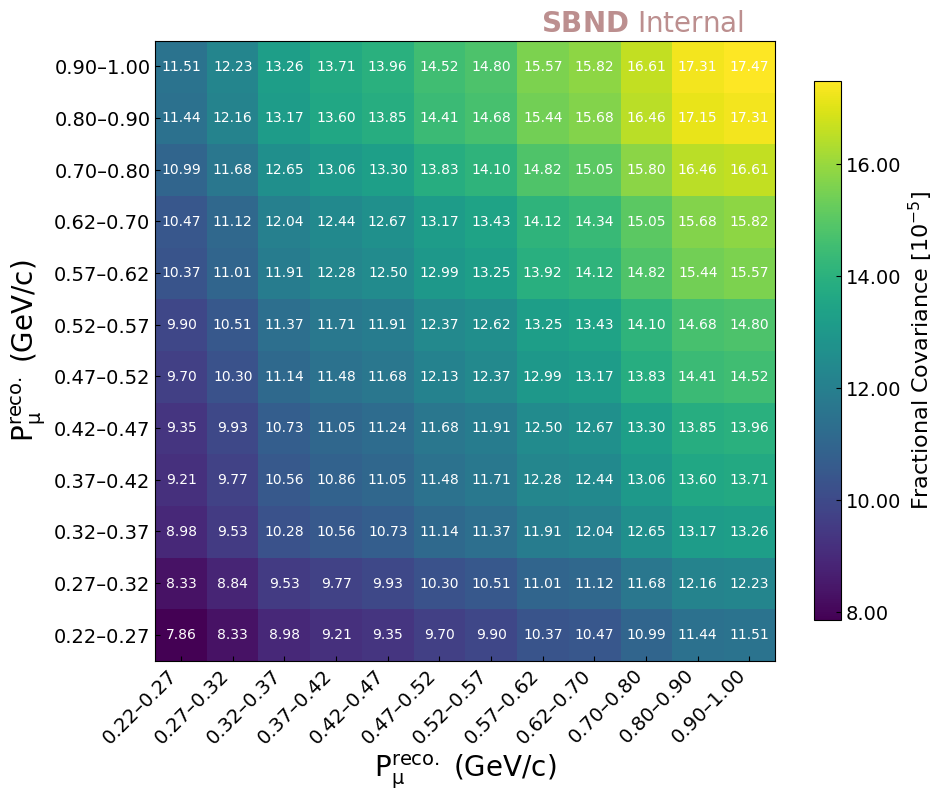

 17%|█▋        | 1/6 [00:27<02:16, 27.32s/it]

getting 1000 universes for ('mc', 'pionqexsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:24<00:00, 41.54it/s]


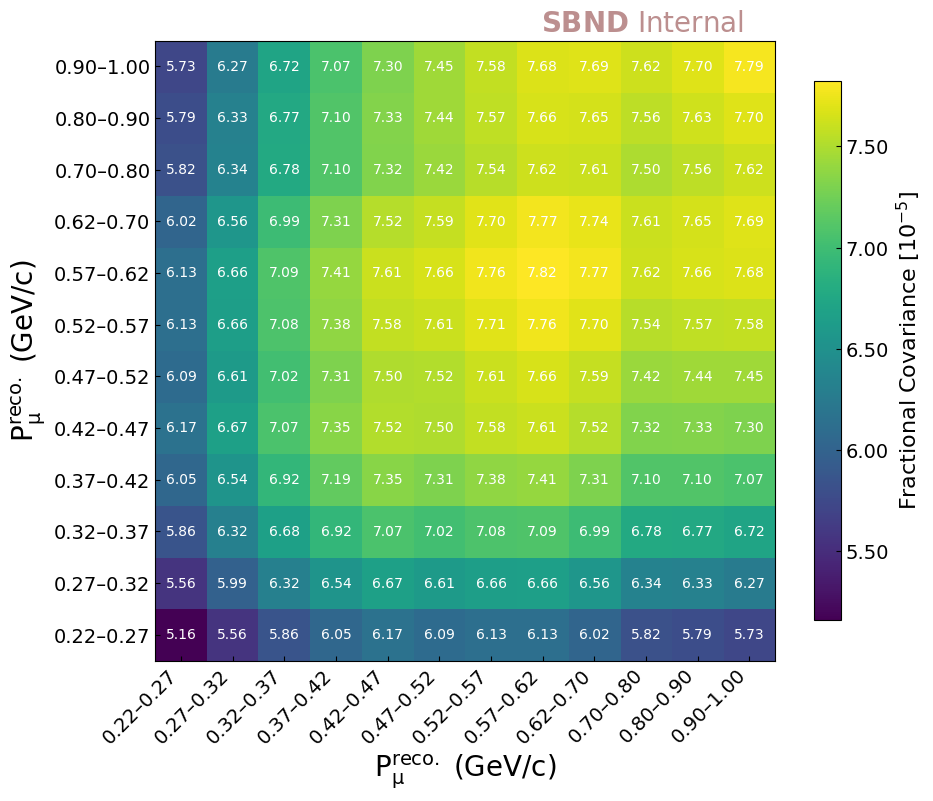

 33%|███▎      | 2/6 [00:52<01:44, 26.04s/it]

getting 1000 universes for ('mc', 'piontotxsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:24<00:00, 40.56it/s]


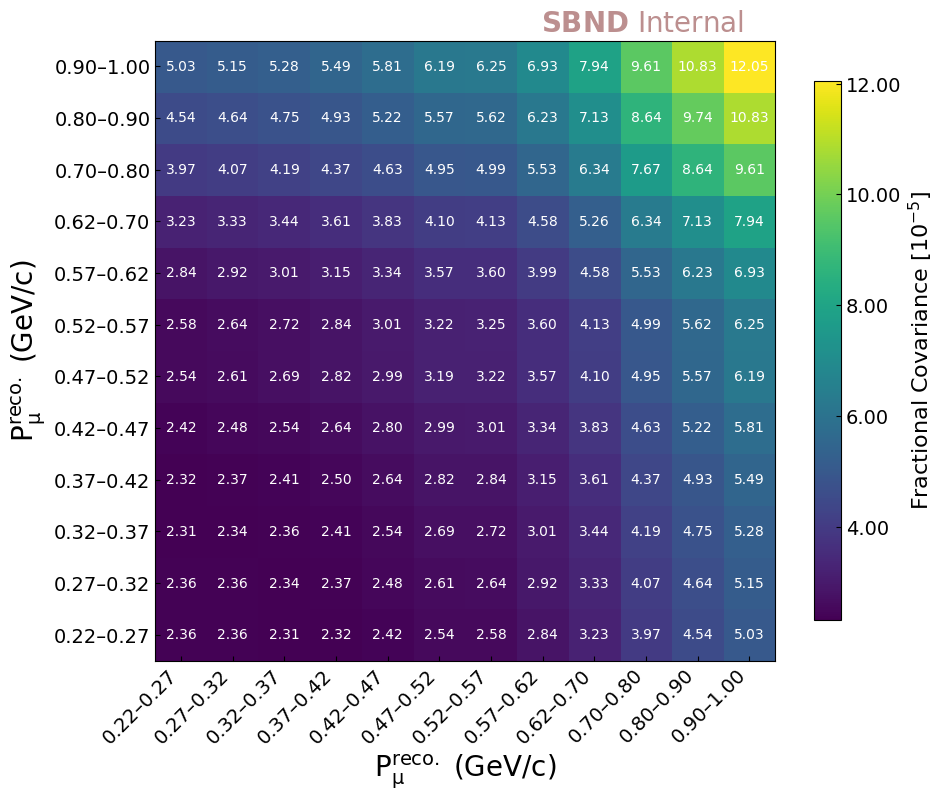

 50%|█████     | 3/6 [01:17<01:17, 25.80s/it]

getting 1000 universes for ('mc', 'nucleoninexsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:24<00:00, 41.36it/s]


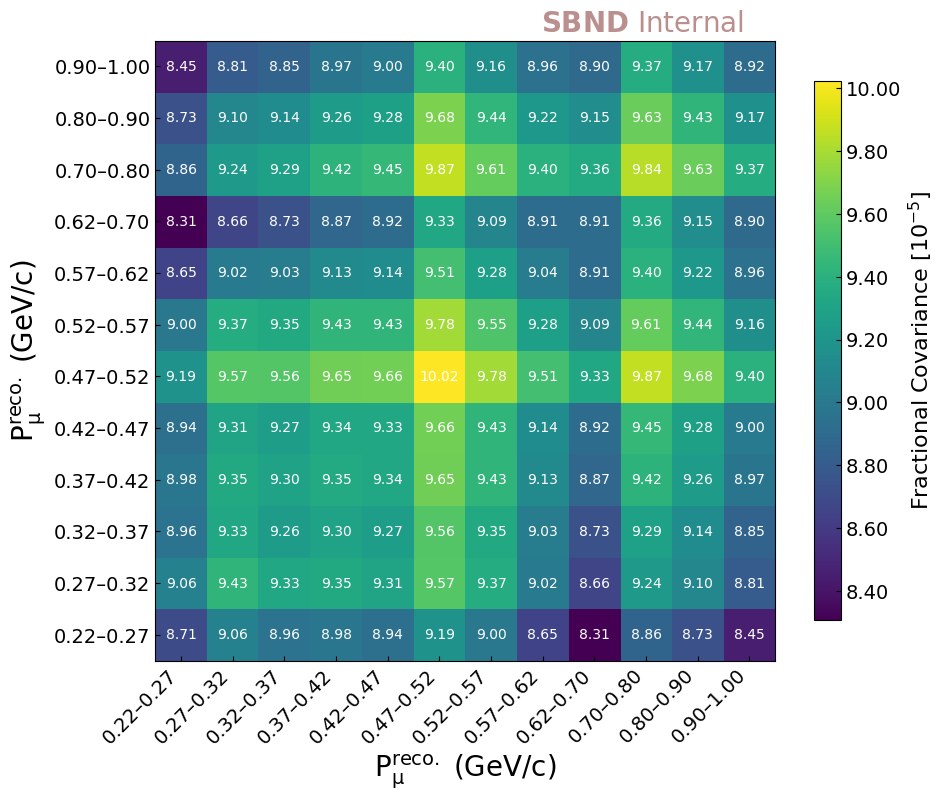

 67%|██████▋   | 4/6 [01:43<00:51, 25.55s/it]

getting 1000 universes for ('mc', 'nucleonqexsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:24<00:00, 40.75it/s]


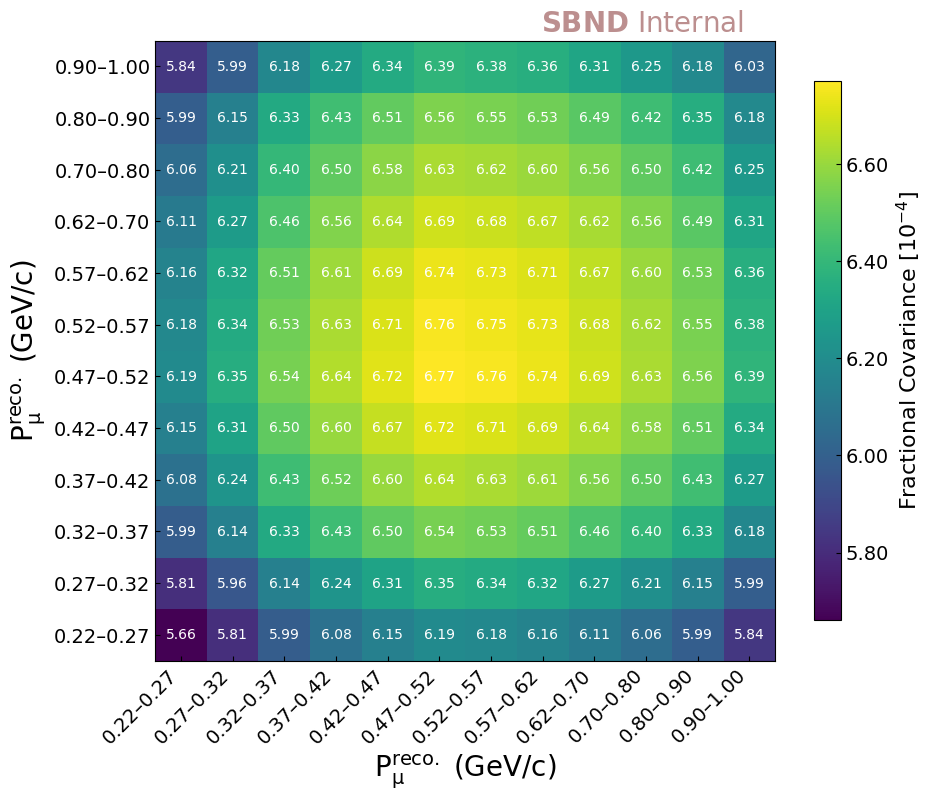

 83%|████████▎ | 5/6 [02:08<00:25, 25.50s/it]

getting 1000 universes for ('mc', 'nucleontotxsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:24<00:00, 41.06it/s]


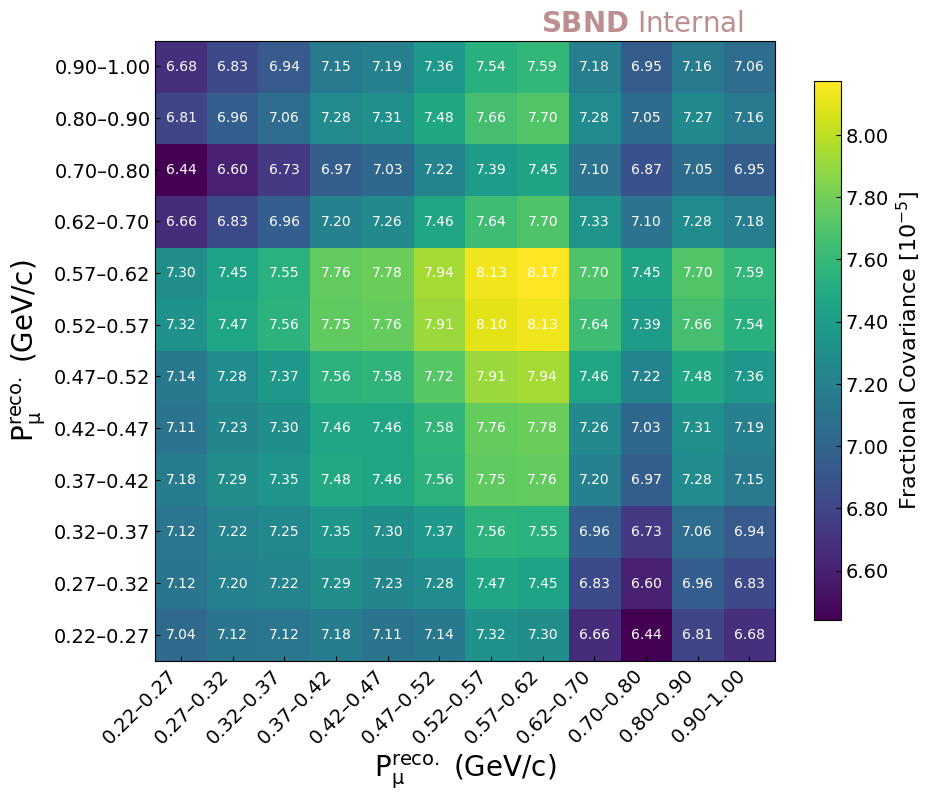

100%|██████████| 6/6 [02:33<00:00, 25.63s/it]


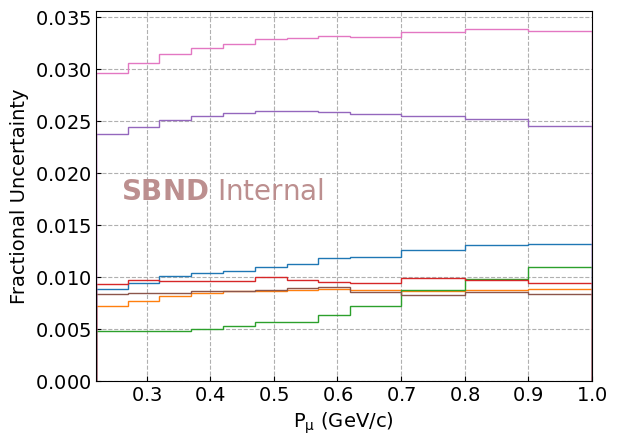

In [14]:
# individual weights, summed cov matrix
cov_type = "rate"
n_univ = 1000

cov_frac_summed = np.zeros((len(var_config.bin_centers), len(var_config.bin_centers)))
frac_unc_list = []

for knob in tqdm(bnb_systematics_xsec):
    syst_name = ("mc", knob)
    univ_events, cv_events = get_univ_rates(cov_type, evtdf=mc_evt_df, nudf=None, bkgd_subtract=False, var_config=var_config, syst_name=syst_name, n_univ=n_univ)
    ret = get_covariance_matrix(univ_events, cv_events)

    matrix_type = "cov_frac"
    plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Fractional Covariance"]
    plot_heatmap(ret[matrix_type], 
                var_config.bins, 
                plot_labels=plot_labels,
                plot=True,
                cmap="viridis",
                save_fig=save_fig, save_name=None)

    cov_frac_summed += ret["cov_frac"]
    frac_unc_list.append(np.sqrt(np.diag(ret["cov_frac"])))

frac_unc_list  = frac_unc_list + [np.sqrt(np.diag(cov_frac_summed))]
plot_frac_unc(frac_unc_list, var_config)

getting 1000 universes for ('mc', 'Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [02:02<00:00,  8.15it/s]


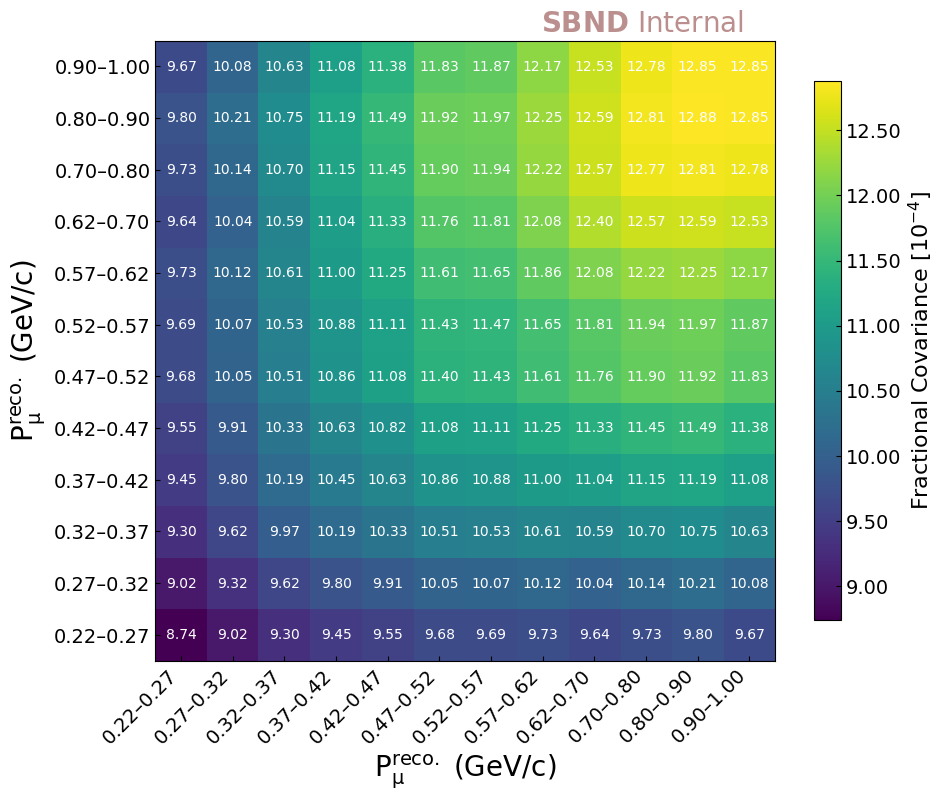

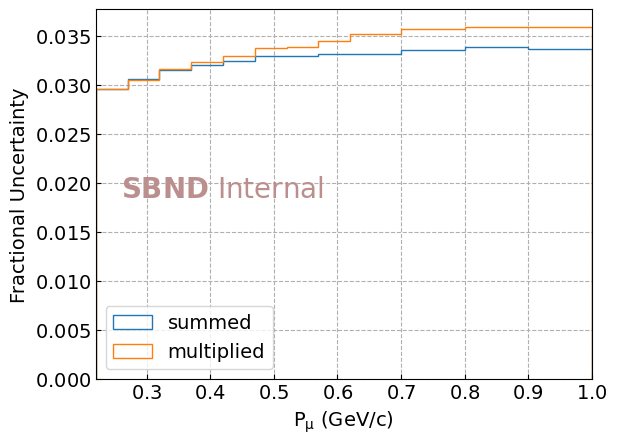

In [15]:
# multiplied weights
cov_type = "rate"
syst_name = ("mc", "Flux")
univ_events, cv_events = get_univ_rates(cov_type, evtdf=mc_evt_df, nudf=None, bkgd_subtract=False, var_config=var_config, syst_name=syst_name, n_univ=n_univ)
ret = get_covariance_matrix(univ_events, cv_events)

matrix_type = "cov_frac"
plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Fractional Covariance"]
plot_heatmap(ret[matrix_type], 
            var_config.bins, 
            plot_labels=plot_labels,
            plot=True,
            cmap="viridis",
            save_fig=save_fig, save_name=None)

unc_list = [np.sqrt(np.diag(cov_frac_summed))] + [np.sqrt(np.diag(ret["cov_frac"]))]
plot_frac_unc(unc_list, var_config, legends = ["summed", "multiplied"])

In [19]:
# Corner plot to inspect correlations between knobs
import corner

# Collect the covariance diagonals for each knob
# Each vector is the deviation for each universe (flattened in bin space)
knob_samples = []

for knob in bnb_systematics_xsec:
    syst_name = ("mc", knob)
    univ_events, cv_events = get_univ_rates(cov_type, evtdf=mc_evt_df, nudf=None, bkgd_subtract=False, var_config=var_config, syst_name=syst_name, n_univ=n_univ)
    # shape: (n_univ, n_bins)
    # For each universe, get fractional shift compared to CV
    frac_shift = (univ_events - cv_events) / (cv_events + 1e-12)  # Avoid div by zero
    # Take the mean shift per universe over bins, or flatten all bins
    # We flatten all bins for strictest test
    knob_samples.append(frac_shift.flatten())

# Stack into (n_knobs, n_univ * n_bins) shape, then transpose
knob_samples = np.array(knob_samples)  # shape: (n_knobs, n_univ * n_bins)
# For corner.py, want shape: (n_samples, n_knobs) - so rows = independent points
knob_samples = knob_samples.T  # shape: (n_samples, n_knobs)

knob_labels = [str(k) for k in bnb_systematics_xsec]

getting 1000 universes for ('mc', 'pioninexsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:24<00:00, 41.49it/s]


getting 1000 universes for ('mc', 'pionqexsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:23<00:00, 41.85it/s]


getting 1000 universes for ('mc', 'piontotxsec_Flux') uncertainty on the event rate


...

Getting universes: 100%|██████████| 1000/1000 [00:24<00:00, 40.08it/s]


getting 1000 universes for ('mc', 'nucleonqexsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:23<00:00, 42.17it/s]


getting 1000 universes for ('mc', 'nucleontotxsec_Flux') uncertainty on the event rate


Getting universes: 100%|██████████| 1000/1000 [00:23<00:00, 41.93it/s]


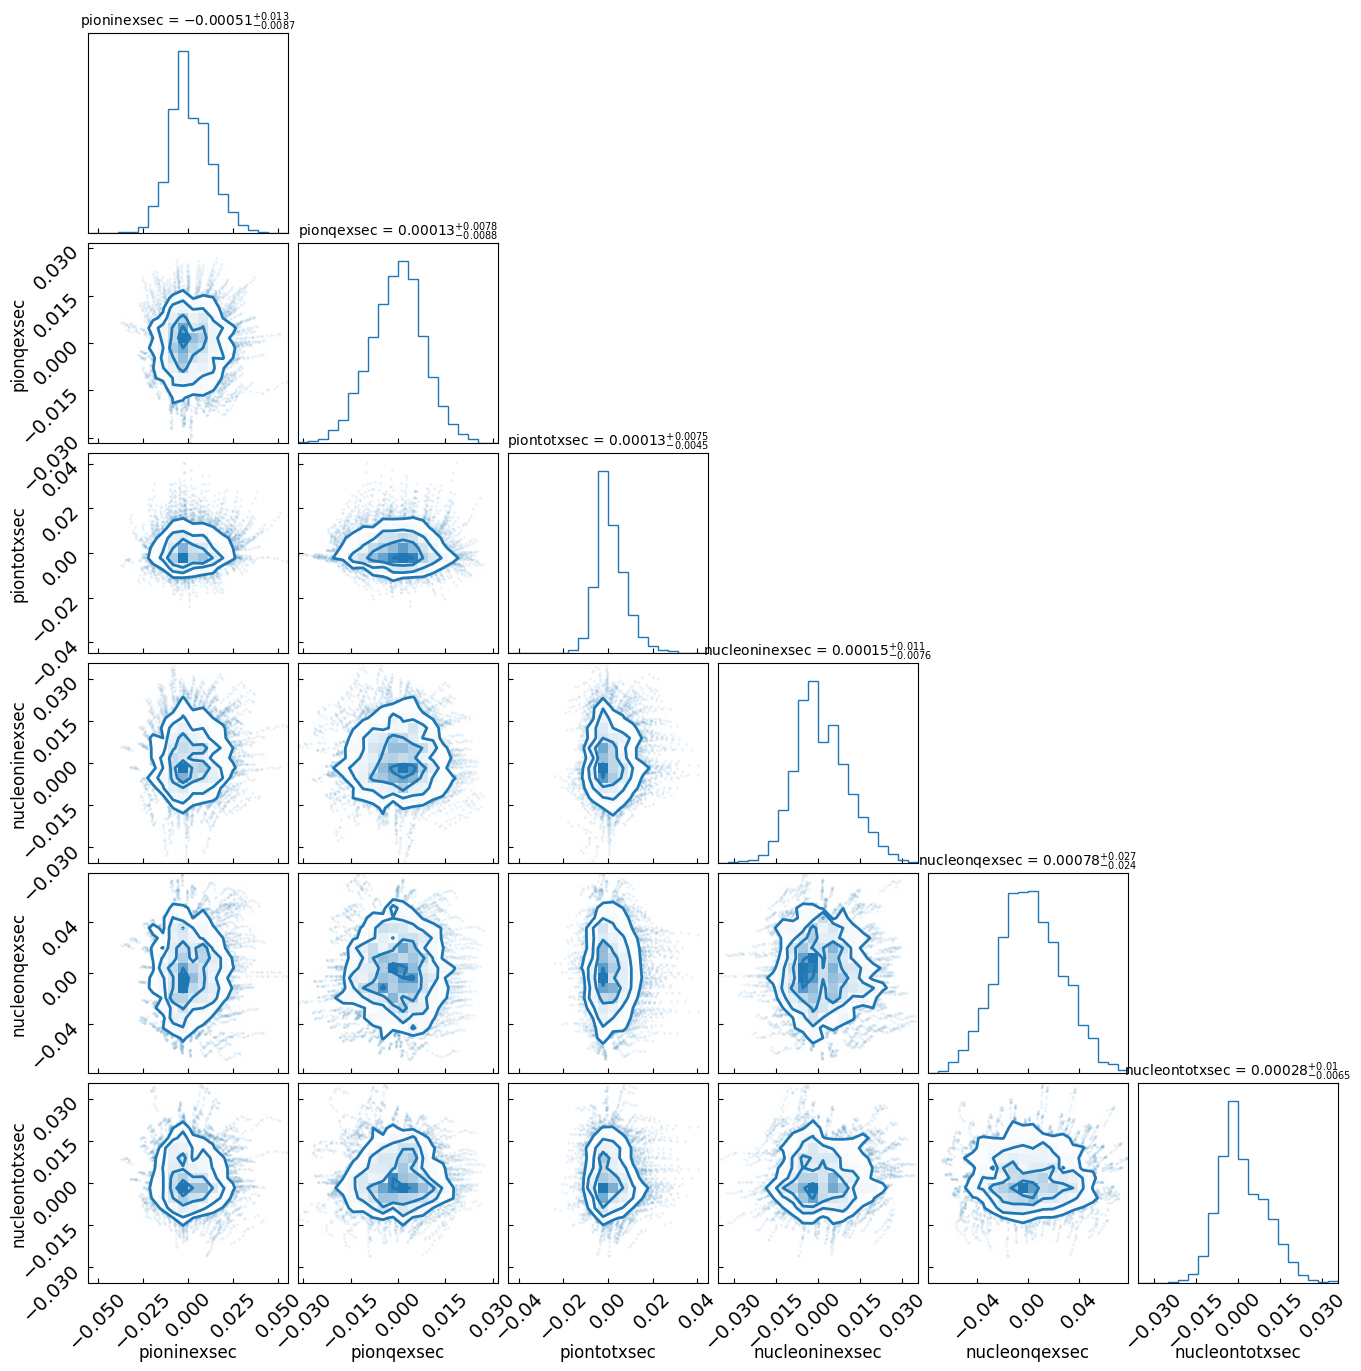

In [23]:
fig = corner.corner(knob_samples, 
                   labels=[k[:-5] if k.endswith("_Flux") else k for k in knob_labels], 
                   show_titles=True, title_fmt=".2g", 
                   color="C0", 
                   label_kwargs={"fontsize": 12},
                   title_kwargs={"fontsize": 10},
                   plot_contours=True,
                   hist_kwargs={"density": True},
                   range=[(-np.max(np.abs(knob_samples[:,i])), np.max(np.abs(knob_samples[:,i]))) for i in range(knob_samples.shape[1])]
                   )

plt.show()

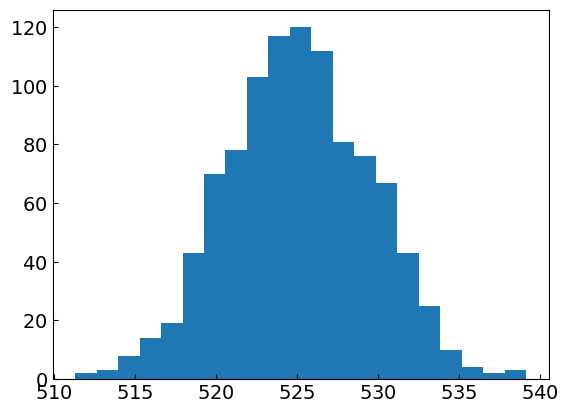

In [17]:
var = univ_events[:, 0]
bins = 21
plt.hist(var, bins=bins)
plt.show()


### DEBUG end

In [ ]:
flux_dict = {}
syst_name = ("mc", "Flux")

for var_config in tqdm(var_configs):
    univ_events, cv_events = get_univ_rates(evtdf=mc_evt_df,
                                            var_config=var_config,
                                            n_univ=100,
                                            bkgd_subtract=True,
                                            syst_name=syst_name)
    ret = get_covariance_matrix(univ_events, cv_events)

    save_fig_name = "{}/{}-{}-universes".format(save_fig_dir, var_config.var_save_name, syst_name[1])
    plot_univ_hists(univ_events, cv_events, syst_name, var_config, save_fig=save_fig, save_name=save_fig_name)

    frac_unc = np.sqrt(np.diag(ret["cov_frac"]))
    plot_frac_unc([frac_unc], var_config)


    matrix_type = "cov_frac"
    save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name, matrix_type)
    title = "{} {}".format(syst_name, matrix_type)
    plot_heatmap(ret[matrix_type], 
                var_config.bins, 
                plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Fractional Covariance"],
                save_fig=save_fig, save_name=save_fig_name)

    flux_dict[var_config.var_save_name] = {}
    flux_dict[var_config.var_save_name]["flux"] = ret

# G4

In [ ]:
g4_dict = {}
syst_name = ("mc", "G4")

for var_config in tqdm(var_configs):
    univ_events, cv_events = get_univ_rates(evtdf=mc_evt_df,
                                            var_config=var_config,
                                            n_univ=100,
                                            bkgd_subtract=True,
                                            syst_name=syst_name)
    ret = get_covariance_matrix(univ_events, cv_events)

    save_fig_name = "{}/{}-{}-universes".format(save_fig_dir, var_config.var_save_name, syst_name[1])
    plot_univ_hists(univ_events, cv_events, syst_name, var_config, save_fig=save_fig, save_name=save_fig_name)

    frac_unc = np.sqrt(np.diag(ret["cov_frac"]))
    plot_frac_unc([frac_unc], var_config)

    matrix_type = "cov_frac"
    save_fig_name = "{}/{}-{}-{}".format(save_fig_dir, var_config.var_save_name, syst_name, matrix_type)
    title = "{} {}".format(syst_name, matrix_type)
    plot_heatmap(ret[matrix_type], 
                var_config.bins, 
                plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Covariance"],
                save_fig=save_fig, save_name=save_fig_name)

    g4_dict[var_config.var_save_name] = {}
    g4_dict[var_config.var_save_name]["G4"] = ret

# Cosmics

take the difference between the offbeam data and intime MC as a unisim uncertainty

In [ ]:
mc_evt_df_bnb = mc_evt_df

dfs = get_ana_dfs(option="cosmics_systs")
data_evt_df = dfs["data"]
mc_evt_df = dfs["mc"]

In [ ]:
data_evt_df

In [ ]:
cosmics_dict = {}
for var_config in var_configs:

    univ_events, cv_events = get_univ_rates(evtdf=mc_evt_df_bnb,
                                            var_config=var_config,
                                            n_univ=100,
                                            bkgd_subtract=True,
                                            syst_name=("mc", "Flux"))

    fig, ax = plt.subplots()

    data_events, _, _ = plt.hist(data_evt_df[var_config.var_evt_reco_col], bins=var_config.bins, histtype="step", color="red", label="Data")
    mc_events, _, _   = plt.hist(mc_evt_df[var_config.var_evt_reco_col], weights=mc_evt_df["pot_scale"], bins=var_config.bins, histtype="step", color="black", label="MC")

    if var_config.var_save_name == "integrated":
        data_events = np.array([len(data_evt_df)])
        mc_events = np.array([len(mc_evt_df)])
        print(data_events, mc_events)
        # ret["cov_frac"][-1, -1] = 0.001

    # fill 0 with 1
    mc_events[mc_events == 0] = 1
    data_events[data_events == 0] = 1

    plt.xlim(var_config.bins[0], var_config.bins[-1])
    plt.xlabel(var_config.var_labels[0])
    plt.ylabel("Events / Bin")
    plt.legend()

    save_fig_name = "{}/{}-{}-universes.pdf".format(save_fig_dir, var_config.var_save_name, "Cosmics")
    plt.savefig(save_fig_name, bbox_inches="tight", dpi=dpi)
    plt.show();

    # treat data as a unisim systematic universe
    # the MC-data difference is the variation in event rate
    syst_name = "cosmics"
    univ_events =np.array([cv_events + (data_events - mc_events)])

    ret = get_covariance_matrix(univ_events, cv_events)


    plot_univ_hists(univ_events, cv_events, syst_name, var_config)

    frac_unc = np.sqrt(np.diag(ret["cov_frac"]))
    plot_frac_unc([frac_unc], var_config)

    matrix_type = "cov"
    save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name, matrix_type)
    title = "{} {}".format(syst_name, matrix_type)
    plot_heatmap(ret[matrix_type], 
                var_config.bins, 
                plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Covariance"],
                save_fig=save_fig, save_name=save_fig_name)

    cosmics_dict[var_config.var_save_name] = {}
    cosmics_dict[var_config.var_save_name]["Cosmics"] = ret

In [ ]:
cosmics_dict.keys()

In [ ]:
syst_type = "cosmics"
print("saving dict with keys: ", cosmics_dict.keys())
print("for systs: ", cosmics_dict[list(cosmics_dict.keys())[0]].keys())
save_filename = f"{save_fig_dir}/{syst_type}_syst_dict.npz"
print("saving cosmics_dict as npz in %s" % (save_filename))
np.savez(save_filename, **cosmics_dict)

# GENIE

- load and combine systematics calculated per-source

In [ ]:
cov_mat_dict = {}
for var_config in var_configs:
    cov_mat_dict[var_config.var_save_name] = {
        # Ar23+ (all)
        "genie": np.zeros((len(var_config.bin_centers), len(var_config.bin_centers))),
        "genie_rate": np.zeros((len(var_config.bin_centers), len(var_config.bin_centers))),
        # Ar23
        "genie_ar23": np.zeros((len(var_config.bin_centers), len(var_config.bin_centers))),
        "genie_ar23_rate": np.zeros((len(var_config.bin_centers), len(var_config.bin_centers))),
    }

In [ ]:
# read matrices from GENIE syst script output files
base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
date_str = "20260225"

for genie_tag in ["CCQE", "MEC", "RES", "nonRES", "DIS", "Other", "Ar23p"]:
    unc_file = path.join(base_dir, f"systematics-genie-{genie_tag}-{date_str}", f"genie-{genie_tag}_syst_dict.npz")
    unc_arr = np.load(unc_file, allow_pickle=True)
    unc_dict = dict(unc_arr)

    for var_config in var_configs:
        syst_keys = list(unc_dict[var_config.var_save_name].item().keys())
        for k in syst_keys:

            # TODO: CRPA syst is bugged, skip for now...
            if "CRPA" in k:
                continue

            syst_uncert_xsec = np.sqrt(np.diag(unc_dict[var_config.var_save_name].item()[k]["xsec"]["cov_frac"]))
            syst_uncert_rate = np.sqrt(np.diag(unc_dict[var_config.var_save_name].item()[k]["rate"]["cov_frac"]))

            cov_mat_dict[var_config.var_save_name][k] = unc_dict[var_config.var_save_name].item()[k]["xsec"]["cov_frac"]
            cov_mat_dict[var_config.var_save_name][k+"_rate"] = unc_dict[var_config.var_save_name].item()[k]["rate"]["cov_frac"]

            cov_mat_dict[var_config.var_save_name]["genie"] += unc_dict[var_config.var_save_name].item()[k]["xsec"]["cov_frac"]
            cov_mat_dict[var_config.var_save_name]["genie_rate"] += unc_dict[var_config.var_save_name].item()[k]["rate"]["cov_frac"]

            if genie_tag != "Ar23p":
                cov_mat_dict[var_config.var_save_name]["genie_ar23"] += unc_dict[var_config.var_save_name].item()[k]["xsec"]["cov_frac"]
                cov_mat_dict[var_config.var_save_name]["genie_ar23_rate"] += unc_dict[var_config.var_save_name].item()[k]["rate"]["cov_frac"]

In [ ]:
var_config = VariableConfig.muon_momentum()

In [ ]:
ret = get_ana_dfs(option="genie_systs")
mc_hdr_df = ret['hdr']
mc_nu_df = ret['mcnu']
mc_evt_df = ret['evt']

In [ ]:
# /exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/MC/BNB_cosmics/genie_wgts-Ar23p/test_list.df
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
ret = load_and_concat_mc_dfs(
    file_dir=file_dir,
    sub_dir="MC",
    sample_dir="BNB_cosmics/genie_wgts-Ar23p",
    df_tag="",
    chunk_tags=["test_list"],
    keys2load=['hdr', 'mcnu', 'evt'],
    n_max_concat=999
)

In [ ]:
mc_hdr_df = ret['hdr']
mc_nu_df = ret['mcnu']
mc_evt_df = ret['evt']

In [ ]:
# syst_name = ("mc", "GENIE")
syst_name = ("mc", 'MECq0q3InterpWeighting_SuSAv2ToValenica_q0binned_MECResponse_q0bin0')

In [ ]:
# mc_nu_df.columns = pd.MultiIndex.from_tuples([tuple(["mc"] + list(c)) for c in mc_nu_df.columns])     # match # of column levels

# # print("==== breakdown of selected events ====")
# mc_evt_df["topo_categ"] = get_topo_category(mc_evt_df)
# mc_evt_df["genie_categ"] = get_genie_category(mc_evt_df)
print(mc_evt_df.topo_categ.value_counts())
print(mc_evt_df.genie_categ.value_counts())

# # print("==== breakdown of all MC events ====")
# mc_nu_df["topo_categ"] = get_topo_category(mc_nu_df)
# mc_nu_df["genie_categ"] = get_genie_category(mc_nu_df)
print(mc_nu_df.topo_categ.value_counts())
print(mc_nu_df.genie_categ.value_counts())

In [ ]:
signal_hists(evtdf=mc_evt_df, 
             nudf=mc_nu_df, 
             var_config=var_config, 
             save_fig=save_fig, 
             save_name=None)

In [ ]:
n_univ = len([c for c in mc_evt_df[syst_name].columns if "univ" in c[0]])

In [ ]:
# Note: these are background subtracted
cov_type = "xsec"
univ_events, cv_events = get_univ_rates(cov_type, mc_evt_df, mc_nu_df, var_config, syst_name, n_univ)
ret_xsec = get_covariance_matrix(univ_events, cv_events)
plot_univ_hists(univ_events, cv_events, syst_name, var_config)

cov_type = "rate"
univ_events, cv_events = get_univ_rates(cov_type, mc_evt_df, mc_nu_df, var_config, syst_name, n_univ)
ret_rate = get_covariance_matrix(univ_events, cv_events)
plot_univ_hists(univ_events, cv_events, syst_name, var_config)

In [ ]:
matrix_type = "cov"
save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name[1], matrix_type)
title = "{} {}".format(syst_name, matrix_type)
plot_heatmap(ret_xsec[matrix_type], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Covariance"],
             save_fig=save_fig, save_name=save_fig_name)
save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name[1]+"_rate", matrix_type)
plot_heatmap(ret_rate[matrix_type], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Covariance"],
             save_fig=save_fig, save_name=save_fig_name)

matrix_type = "cov_frac"
save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name[1], matrix_type)
title = "{} {}".format(syst_name, matrix_type)
plot_heatmap(ret_xsec[matrix_type], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Fractional Covariance"],
             save_fig=save_fig, save_name=save_fig_name)
save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name[1]+"_rate", matrix_type)
plot_heatmap(ret_rate[matrix_type], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Fractional Covariance"],
             save_fig=save_fig, save_name=save_fig_name)

matrix_type = "corr"
save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name[1], matrix_type)
title = "{} {}".format(syst_name, matrix_type)
plot_heatmap(ret_xsec[matrix_type], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Correlation"],
             save_fig=save_fig, save_name=save_fig_name)
save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name[1]+"_rate", matrix_type)
plot_heatmap(ret_rate[matrix_type], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[1], var_config.var_labels[1], "Correlation"],
             save_fig=save_fig, save_name=save_fig_name)

In [ ]:
frac_unc_list = [np.sqrt(np.diag(ret_xsec["cov_frac"])), np.sqrt(np.diag(ret_rate["cov_frac"]))]
plot_frac_unc(frac_unc_list, var_config)